In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [3]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN, ResidualMLP
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics

# print(jax.devices("gpu"))
print(jax.default_backend())

gpu


# configuration

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

i_snapshots = None
# i_snapshots = [-2,-1]
# i_snapshots = range(1, 33+8, 8)
# i_snapshots = range(1, 33+4, 4)
# i_snapshots = np.arange(-4, 0, dtype=int)
# i_snapshots = np.arange(-8, 0, dtype=int)
# i_snapshots = np.arange(0, 4, dtype=int)

# i_snapshots = np.arange(10, 20, dtype=int)
# i_snapshots = np.arange(20, 24, dtype=int)

# CAMELS

In [5]:
out_dict = camels.load_CV_snapshots(
    "CV_0",
    # "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
    # CODE="Astrid",
    # CODE="IllustrisTNG",
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

# init_dm_pos = dm_poss[0]
# init_dm_vel = dm_vels[0]
# init_gas_pos = gas_poss[0]
# init_gas_vel = gas_vels[0]

Loaded /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5


In [6]:
dt0 = 0.01

print(np.diff(scales))
assert np.all(np.diff(scales) > dt0)

[0.02380952 0.03333333 0.02222222 0.02777778 0.01224106 0.01284044
 0.01346916 0.01412867 0.01482047 0.01554614 0.01630734 0.01710582
 0.0179434  0.01882198 0.01974359 0.02071031 0.02172438 0.0227881
 0.0239039  0.02507434 0.02630208 0.02758995 0.02894087 0.03035793
 0.03184439 0.03340362 0.03503921 0.03675488 0.03855455 0.04044235
 0.04242258 0.04449977 0.04667867]


In [7]:
# i_0 = -4
# # i_1 = -1

# scales = out_dict["scales"][i_0:]

# dm_poss = out_dict["dm_poss"][i_0:]
# dm_vels = out_dict["dm_vels"][i_0:]

# gas_poss = out_dict["gas_poss"][i_0:]
# gas_vels = out_dict["gas_vels"][i_0:]


In [8]:
scales

array([0.14285714, 0.16666667, 0.2       , 0.22222222, 0.25      ,
       0.26224106, 0.2750815 , 0.28855066, 0.30267933, 0.3174998 ,
       0.33304594, 0.34935328, 0.36645911, 0.38440251, 0.40322449,
       0.42296808, 0.44367839, 0.46540277, 0.48819088, 0.51209478,
       0.53716912, 0.5634712 , 0.59106115, 0.62000202, 0.65035996,
       0.68220435, 0.71560797, 0.75064719, 0.78740207, 0.82595662,
       0.86639898, 0.90882155, 0.95332133, 1.        ])

In [9]:
# vali_dict = camels.load_CV_snapshots(
#     "CV_1",
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     return_hydro=True,
# )

In [10]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [11]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)
    return loss, grad_norm

losses = []

In [12]:
# @nnx.jit
# def train_step(model, optimizer, y0, ts, ref):
#     """JIT-compatible training step with dynamic snapshot range"""
    
#     def loss_fn_wrapper(model):
#         return particle_loss_fn(model, y0, ts, ref, "mlp", eps=1e-8)
        
#     loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
#     optimizer.update(grads)

#     squared_sum = jax.tree_util.tree_reduce(
#             lambda x, y: x + jnp.sum(y**2),
#             grads,
#             0.0
#         )
#     grad_norm = jnp.sqrt(squared_sum)
    
#     return loss, grad_norm

In [13]:
@nnx.jit
def batched_train_step(model, optimizer, y0_batch, ts_batch, ref_batch):
    """Training step with batched inputs"""
    
    def loss_fn_wrapper(model):
        return batched_particle_loss_fn(model, y0_batch, ts_batch, ref_batch, "mlp", eps=1e-8)
        
    loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
    optimizer = optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)
    
    return loss, grad_norm

In [14]:
# latent_init = cic_read(cic_paint(jnp.zeros(mesh_shape), gas_poss[0]), gas_poss[0])
# latent_init = jnp.expand_dims(latent_init, axis=-1)

# latent_init = jnp.ones((parts_per_dim**3,1))
# latent_init = jnp.ones((parts_per_dim**3,8))
# latent_init = np.random.normal(loc=1.0, scale=0.01, size=(parts_per_dim**3,4))

# for field cnn
# latent_init = np.random.normal(loc=1.0, scale=0.01, size=tuple(mesh_shape) + (4,))

latent_init = None

In [15]:
edges = graph.get_edges(gas_poss, scales, k=4)

def solve_ode_diffrax(model, architecture, with_latent=True):
    if latent_init is not None:
        y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init)
    else:
        y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])
    
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gravity_model=None, pressure_model=model, gas_architecture=architecture, precomputed_edges=edges)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            # dt0=0.02,
            # dt0=(scales[-1] - scales[0])/(2*len(scales)),
            dt0=0.01,
            y0=y0,
            saveat=SaveAt(ts=scales),
            # max_steps=100,
            stepsize_controller=ConstantStepSize(),
            # adjoint=diffrax.BacksolveAdjoint(),
        )
    res = res.ys

    return res

def solve_ode_sub(model, y0, ts, architecture, training=True):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            gravity_model=None, 
            pressure_model=model, 
            gas_architecture=architecture, 
            training=training,
        )
    )

    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=ts[0],
            t1=ts[-1],
            dt0=dt0,
            y0=y0,
            saveat=SaveAt(ts=ts),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res


In [16]:
# solve_ode_diffrax(model, architecture);

# loss

### CAMELS ground truth

In [17]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# # velocity
# vel_mean_ref = jax.vmap(
#     jax.vmap(
#         cic_paint, 
#         in_axes=(None,0,0)
#     ),
#     in_axes=(None,None,-1), out_axes=-1,
# )(jnp.zeros(mesh_shape), ref_pos, ref_vel / ref_N[..., jnp.newaxis])

# ref_vel_mean = jax.vmap(
#     jax.vmap(
#         cic_read, 
#         in_axes=(0,0)
#     ),
#     in_axes=(-1,None), out_axes=-1,
# )(vel_mean_ref, ref_pos)

# ref_vel_disp = jnp.sum((ref_vel_mean - ref_vel) ** 2, axis=-1)

# field-level reference
gas_mass = cosmo.Omega_b / (cosmo.Omega_b + cosmo.Omega_c)
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# power spectrum reference
vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
_, ref_cls = vpower_spectrum(ref_rho)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [18]:
# res = solve_ode_diffrax(model, architecture)
# gas_poss = res[2]
# res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# kbins, res_cross = vcross_correlation(res_rho)

In [19]:
# k = kbins[0]
# k_min = k[0]
# k_cutoff = k[int(0.2*len(k))]
# k_weights = jnp.exp(-(k - k[0]) / k_cutoff)

# plt.plot(k, k_weights)
# # plt.ylim(0,1)
# plt.xscale("linear")
# plt.yscale("log")
# plt.show()

# plt.plot(k, res_cross[-1], label="original")
# plt.plot(k, k_weights * res_cross[-1], label="weighted")
# plt.xscale("linear")
# plt.yscale("log")
# plt.legend()
# plt.show()

### particle-level

In [20]:
def particle_loss_fn(model, architecture):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]%mesh_per_dim
    gas_vels = res[3]

    pos_loss = jnp.sum((gas_poss - ref_pos)**2, axis=-1)
    pos_loss = jnp.where(pos_loss < mesh_per_dim//2, pos_loss, 0.)
    # pos_loss *= jnp.expand_dims(scales, axis=1)
    pos_loss = jnp.mean(pos_loss)

    vel_loss = jnp.sum((gas_vels - ref_vel)**2, axis=-1)
    vel_loss = jnp.where(vel_loss < mesh_per_dim//2, vel_loss, 0.)
    # vel_loss *= jnp.expand_dims(scales, axis=1)
    vel_loss = jnp.mean(vel_loss)

    res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    _, res_cls = vpower_spectrum(res_rho)
    cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))

    # _, res_cross = vcross_correlation(res_rho)
    # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

    return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
    # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
    # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss + 1 * cross_loss
    # return cl_loss
    # return cross_loss
    # return cl_loss
    # return pos_loss + 0.01 * vel_loss
    # return pos_loss + 0.01 * vel_loss
    # return pos_loss + vel_loss
    # return pos_loss


In [21]:
# def particle_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     # pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
#     pos_loss = jnp.mean(pos_loss)

#     # vel_disp = jnp.std(gas_vels, axis=0)
#     # vel_loss = jnp.sum(((gas_vels - ref_vel) / (vel_disp + 1e-5))**2, axis=-1)
#     # vel_loss = jnp.mean(vel_loss)

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     _, res_cls = vpower_spectrum(res_rho)
#     cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))

#     # _, res_cross = vcross_correlation(res_rho)
#     # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

#     return pos_loss + 0.1 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.01 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss + 1 * cross_loss
#     # return cl_loss
#     # return cross_loss
#     # return cl_loss
#     # return pos_loss + 0.01 * vel_loss
#     # return pos_loss + 0.01 * vel_loss
#     # return pos_loss + vel_loss
#     # return pos_loss


In [22]:
# def particle_loss_fn(model, architecture, huber=False, pos_dead_zone=False, eps=1e-8):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     if huber:
#         pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
#     else:
#         pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     if pos_dead_zone:
#         pos_loss = jnp.where(jnp.sqrt(pos_loss) < 1/mesh_per_dim, 0.0, pos_loss)

#     # pos_loss = jnp.where(jax.lax.is_finite(pos_loss), pos_loss, 0.0)
#     pos_loss = jnp.mean(pos_loss)
#     # print(pos_loss)

#     # vel_loss = jnp.sum(((gas_vels - ref_vel) / (jnp.sqrt(ref_vel_disp[...,np.newaxis]) + 1e-5))**2, axis=-1)
#     # vel_loss = jnp.sum((gas_vels - ref_vel)**2, axis=-1)
#     # vel_loss = jnp.mean(vel_loss)
#     # print(vel_loss)
    
#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     kbins, res_cls = vpower_spectrum(res_rho)

#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/(ref_cls + eps) - 1)*k_weights)**2, axis=-1)

#     # cl_loss = jnp.where(jax.lax.is_finite(cl_loss), cl_loss, 0.0)
#     cl_loss = jnp.mean(cl_loss)

#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
#     # print(cl_loss)
    
#     # _, res_cross = vcross_correlation(res_rho)
#     # cross_loss = jnp.sum(((res_cross/jnp.sqrt(ref_cls * res_cls) - 1) * k_weights)**2)
#     # # cross_loss = jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2)
#     # cross_loss = jnp.mean(cross_loss)

#     # dm_force, gas_force, d_gas_latent = jax.vmap(
#     #     lambda scale, dm_p, gas_p, gas_v, gas_l: hpm.hpm_forces(
#     #         mesh_per_dim, cosmo, scale, dm_p, gas_p, 
#     #         gas_model=model, gas_architecture=architecture,
#     #         gas_vel=gas_v, gas_latent=gas_l,
#     #     ),
#     #     in_axes=(0, 0, 0, 0, 0)
#     # )(scales, res[0], res[2], res[3], res[4])  

#     # corr_matrix = jax.vmap(lambda array: jnp.corrcoef(array, rowvar=False), in_axes=0)(d_gas_latent)
#     # latent_loss = jnp.square(corr_matrix - jnp.expand_dims(jnp.eye(corr_matrix.shape[1]), axis=0))
#     # latent_loss = jnp.mean(latent_loss)
#     # print(latent_loss)
    
#     # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))
#     # print(cross_loss)

#     # return pos_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
#     return pos_loss + 0.1 * cl_loss
#     # return pos_loss + 0.1 * cl_loss + 0.1 * cross_loss + latent_loss
#     # return cross_loss
#     # return pos_loss + cl_loss + cross_loss

In [23]:
# def particle_loss_fn(model, architecture, huber=True, pos_dead_zone=True):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     if huber:
#         pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
#     else:
#         pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     if pos_dead_zone:
#         pos_loss = jnp.where(jnp.sqrt(pos_loss) < 1/mesh_per_dim, 0.0, pos_loss)
#     pos_loss = jnp.mean(pos_loss)
    
#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     kbins, res_cls = vpower_spectrum(res_rho)

#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/ref_cls - 1)*k_weights)**2, axis=-1)
#     cl_loss = jnp.mean(cl_loss)

#     return pos_loss + 0.1 * cl_loss


In [24]:
# def particle_loss_fn(model, architecture, eps=1e-8):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     pos_loss = jnp.sum(delta_pos**2, axis=-1)

#     # pos_loss /= jnp.maximum(jnp.mean(pos_loss, axis=1, keepdims=True), eps)
#     # pos_loss /= jnp.maximum(scales[:, jnp.newaxis]**3, eps)
#     # pos_loss /= jnp.maximum(scales[:, jnp.newaxis]**4, eps)

#     # print(pos_loss.shape)
#     # pos_loss = pos_loss[-1]
#     pos_loss = jnp.mean(pos_loss)

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     kbins, res_cls = vpower_spectrum(res_rho)

#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)

#     # cl_loss /= jnp.mean(cl_loss, axis=0, keepdims=True)
#     # cl_loss /= jnp.maximum(scales[:,jnp.newaxis]**3, eps)

#     # print(cl_loss.shape)
#     # cl_loss = cl_loss[-1]
#     cl_loss = jnp.mean(cl_loss)

#     return pos_loss + 0.1 * cl_loss
#     # return pos_loss
#     # return cl_loss



In [25]:
# def particle_loss_fn(model, y0, ts, ref, architecture, eps=1e-8):
#     res = solve_ode_sub(model, y0, ts, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     # pos_loss /= jnp.maximum(scales[:, jnp.newaxis]**3, eps)
#     pos_loss = jnp.mean(pos_loss)

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     kbins, res_cls = vpower_spectrum(res_rho)

#     # k = kbins[0]
#     # k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     # k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     # cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)
#     # cl_loss /= jnp.maximum(scales[:,jnp.newaxis]**3, eps)
#     # cl_loss = jnp.mean(cl_loss)

#     # return pos_loss + 0.1 * cl_loss
#     return pos_loss


# def batched_particle_loss_fn(model, y0_batch, ts_batch, ref_batch, architecture, eps=1e-8):
#     """Process multiple initial conditions in a batch"""
#     def single_loss_fn(model, y0, ts, ref):
#         return particle_loss_fn(model, y0, ts, ref, architecture, eps=1e-8)
        
#     batch_losses = jax.vmap(single_loss_fn, in_axes=(None,0,0,0))(model, y0_batch, ts_batch, ref_batch)
    
#     return jnp.mean(batch_losses)

In [26]:
# eps = 1e-8

# res = solve_ode_diffrax(model, architecture)
# gas_poss = res[2]
# gas_vels = res[3]

# delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
# pos_loss = jnp.sum(delta_pos**2, axis=-1)

# res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
# kbins, res_cls = vpower_spectrum(res_rho)

# k = kbins[0]
# k_min, k_cutoff = k[0], k[int(0.2*len(k))]
# k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

# cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)

In [27]:
# res = solve_ode_diffrax(model, architecture)

# dm_force, gas_force, d_gas_latent = jax.vmap(
#     lambda scale, dm_p, gas_p, gas_v, gas_l: hpm.hpm_forces(
#         mesh_per_dim, cosmo, scale, dm_p, gas_p, 
#         gas_model=model, gas_architecture=architecture,
#         gas_vel=gas_v, gas_latent=gas_l,
#     ),
#     in_axes=(0, 0, 0, 0, 0)
# )(scales, res[0], res[2], res[3], res[4])  

# corr_matrix = jax.vmap(lambda array: jnp.corrcoef(array, rowvar=False), in_axes=0)(d_gas_latent)
# latent_loss = jnp.square(corr_matrix - jnp.expand_dims(jnp.eye(corr_matrix.shape[1]), axis=0))
# latent_loss = jnp.mean(latent_loss)


In [28]:
# particle_loss_fn(model, architecture)

In [29]:
# res = solve_ode_diffrax(model, architecture)
# gas_poss = res[2]
# gas_vels = res[3]

In [30]:
# plt.hist((gas_vels - ref_vel).ravel(), bins=100, log=True);

In [31]:
# temp = (gas_vels - ref_vel)/(ref_vel_disp[...,np.newaxis] + 1e-5)
# plt.hist(temp.ravel(), bins=50, log=True);

### field-level

In [32]:
def field_loss_fn(model, architecture, eps=1e-8):
    print("using voxel MSE")
    
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]%mesh_per_dim
    
    rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

    loss = (rho - ref_rho)**2
    # loss /= jnp.maximum(scales.reshape(-1,1,1,1)**2, eps)
    loss = jnp.mean(loss)
        
    return loss

In [33]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim

#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
        
#     eps = 1e-5
#     # rho_loss = jnp.mean((jnp.log1p(rho + eps) - jnp.log1p(ref_rho + eps))**2)
#     # rho_loss = jnp.mean((jnp.log10(rho - ref_rho + eps))**2)
    
#     rho_loss = jnp.mean(jnp.sum((rho - ref_rho)**2, axis=(1,2,3)))

#     # _, res_cls = vpower_spectrum(res_rho)
#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
    
#     return rho_loss
#     # return rho_loss + 0.1 * cl_loss


In [34]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim
    
#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    
#     eps = 1e-8
#     log_rho = jnp.log10(rho + eps)
#     log_ref_rho = jnp.log10(ref_rho + eps)
#     # log_loss = jnp.mean(jnp.sum((log_rho - log_ref_rho)**2, axis=(1,2,3)))
#     log_loss = jnp.mean((log_rho - log_ref_rho)**2)
        
#     return log_loss

# architecture

### MLP

In [35]:
if latent_init is None:
    latent_dim = 0
else:
    latent_dim = latent_init.shape[-1]

model = MLP(
    d_in=5 + latent_dim,
    d_out=1 + latent_dim, 
    d_hidden=64, 
    # d_hidden=128,
    # d_hidden=256,
    # d_hidden=512, 
    n_hidden=4, 
    # n_hidden=2, 
    # dropout_rate=0.0f1,
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="layer",
    # norm_type="batch",
    # norm_type="layer",
    activation=jax.nn.relu,
    # activation=jax.nn.tanh,
    # activation=jax.nn.swish,
)
architecture = "mlp"

In [36]:
# model = ResidualMLP(
#         d_in=5,
#         d_out=1,
#         d_hidden=64,
#         # d_hidden=256,
#         n_blocks=2,
#         rngs=nnx.Rngs(0),
#         dropout_rate=0.0,
#         # activation=jax.nn.relu,
#         activation=jax.nn.swish,
#         # norm_type="batch",
#         norm_type="layer",
# )
# architecture = "mlp"

In [37]:
# nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

# nn_res = diffeqsolve(
#         terms=ODETerm(nn_ode),
#         solver=LeapfrogMidpoint(),
#         t0=scales[0],
#         t1=scales[-1],
#         dt0=0.01,
#         y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
#         # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
#         saveat=SaveAt(ts=scales),
#         max_steps=100,
#         stepsize_controller=ConstantStepSize(),
#         # adjoint=diffrax.BacksolveAdjoint(),
# )

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
# # nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

### CNN

In [38]:
# model = CNN(
#     d_in=4 + latent_dim, 
#     d_out=1,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# architecture = "cnn"

In [39]:
# model = nn.ResNet3D(
#         d_in=4,
#         d_hidden=8,
#         d_out=1,
#         num_blocks=1,
#         rngs=nnx.Rngs(0),
#         kernel_size=(3, 3, 3),
#         strides=1,
# )
# architecture = "cnn"

### MLP + CNN

In [40]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# mlp = MLP(
#     d_in=5 + latent_dim,
#     d_out=8, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + latent_dim, 
#     d_out=8,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + latent_dim, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

In [41]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# mlp = MLP(
#     d_in=5 + latent_dim,
#     d_out=16, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + latent_dim, 
#     d_out=16,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(5, 5, 5),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + latent_dim, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

### CNN

In [42]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# model = CNN(
#     d_in=5 + latent_dim, 
#     d_out=1 + latent_dim,
#     d_hidden=64,
#     # n_hidden=8,
#     n_hidden=4,
#     # kernel_size=(5, 5, 5),
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0),
#     # use_residual=False,
#     # use_residual=False,
#     # norm_type=False,
#     # norm_type="batch",
#     # norm_type="layer",
# )

# architecture = "cnn"

### GNN

on the fly

In [43]:
# with_latent = False

# model = AttentionGNN(
#     d_node=5 + with_latent,
#     d_edge=1,
#     d_query=32,
#     n_hidden=4,
#     d_out=1 + with_latent,
#     rngs=nnx.Rngs(0),
# )

# architecture = "gnn"

# tests

In [44]:
# temp_input = jnp.ones(((mesh_per_dim,) * 3 + (5 + latent_dim,)))

In [45]:
# temp_output = model(temp_input)

In [46]:
# i = -1

# temp_force = hpm.hpm_forces_cnn(
#     mesh_per_dim,
#     cosmo,
#     scales[i],
#     dm_poss[i],
#     gas_poss[i],
#     # gravity
#     gravity_model=None,
#     # pressure
#     pressure_model=model,
#     gas_vel=gas_vels[i],
#     gas_latent=latent_init,
#     gas_architecture="cnn",
# )

# training

In [47]:
total_steps = 100

batch_size = 8
delta_snapshot = 8

learning_rate = 1e-3
# learning_rate = 1e-4
# learning_rate = 1e-5
# learning_rate = 1e-6
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-4, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-5,
#     peak_value=1e-4,
#     end_value=1e-5,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        # optax.clip(clip_norm),
        # optax.adaptive_grad_clip(
        #     clipping=0.01,        # Lower = more aggressive clipping
        #     eps=1e-3                 # Numerical stability constant
        # ),
        optax.clip_by_global_norm(clip_norm),
        # optax.ema(decay=0.999),
        # optax.adamw(learning_rate, b1=0.95, b2= 0.9999, eps=1e-5)
        optax.adamw(learning_rate, eps=1e-5)
    )
)

losses = []
grad_norms = []
loss_fn = lambda model: particle_loss_fn(model, architecture)
# loss_fn = lambda model: field_loss_fn(model, architecture)

In [48]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_rand = np.random.randint(0, len(scales) - delta_snapshot)
#     i0, i1 = i_rand, i_rand + delta_snapshot
    
#     y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
#     ts = scales[i0:i1]
#     ref = ref_pos[i0:i1]
    
#     loss, grad_norm = train_step(model, optimizer, y0, ts, ref)

#     losses.append(float(loss))
#     grad_norms.append(float(grad_norm))
#     pbar.set_description(f"[{i0},{i1}], Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")

# fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
# ax[0].plot(losses)
# ax[0].set(yscale="log", title="loss")

# ax[1].plot(grad_norms)
# ax[1].set(yscale="log", title="norm(grad)")

In [49]:
def create_batch(batch_size):
    y0_batch = []
    ts_batch = []
    ref_batch = []
    
    for _ in range(batch_size):
        i_rand = np.random.randint(0, len(scales) - delta_snapshot)
        i0, i1 = i_rand, i_rand + delta_snapshot
        
        y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
        ts = scales[i0:i1]
        # ref = ref_rho[i0:i1]
        ref = ref_pos[i0:i1]
        
        y0_batch.append(y0)
        ts_batch.append(ts)
        ref_batch.append(ref)

    y0_batch = jax.tree_util.tree_map(
        lambda *xs: jnp.stack(xs), 
        *y0_batch
    )
    ts_batch = jnp.stack(ts_batch, axis=0)
    ref_batch = jnp.stack(ref_batch, axis=0)

    return i0, i1, y0_batch, ts_batch, ref_batch


In [50]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i0, i1, y0_batch, ts_batch, ref_batch = create_batch(batch_size)
    
#     loss, grad_norm = batched_train_step(model, optimizer, y0_batch, ts_batch, ref_batch)

#     losses.append(float(loss))
#     grad_norms.append(float(grad_norm))
#     pbar.set_description(f"[{i0},{i1}], Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")
    
# fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
# ax[0].plot(losses)
# ax[0].set(yscale="log", title="loss")

# ax[1].plot(grad_norms)
# ax[1].set(yscale="log", title="norm(grad)")

Loss: 2.8268, Grad norm: inf: 100%|██████████| 100/100 [02:03<00:00,  1.24s/it]                    


[None]

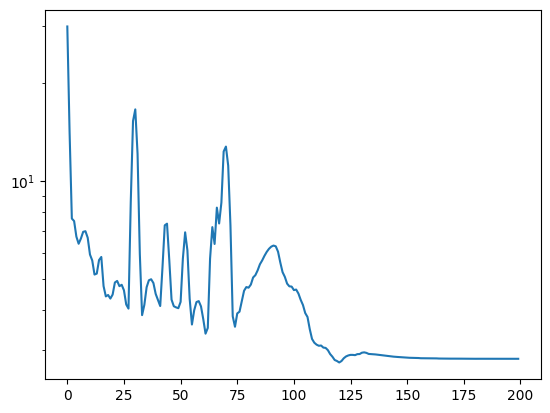

In [57]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss, grad_norm = train_step(model, optimizer, loss_fn)
    
    losses.append(float(loss))
    grad_norms.append(float(grad_norm))
    pbar.set_description(f"Loss: {loss:.4f}, Grad norm: {grad_norm:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

### checkpointing

In [52]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v1_late_time.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v2.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_illustris_v1.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v4_full.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [53]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [54]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:02<00:00,  1.67it/s]


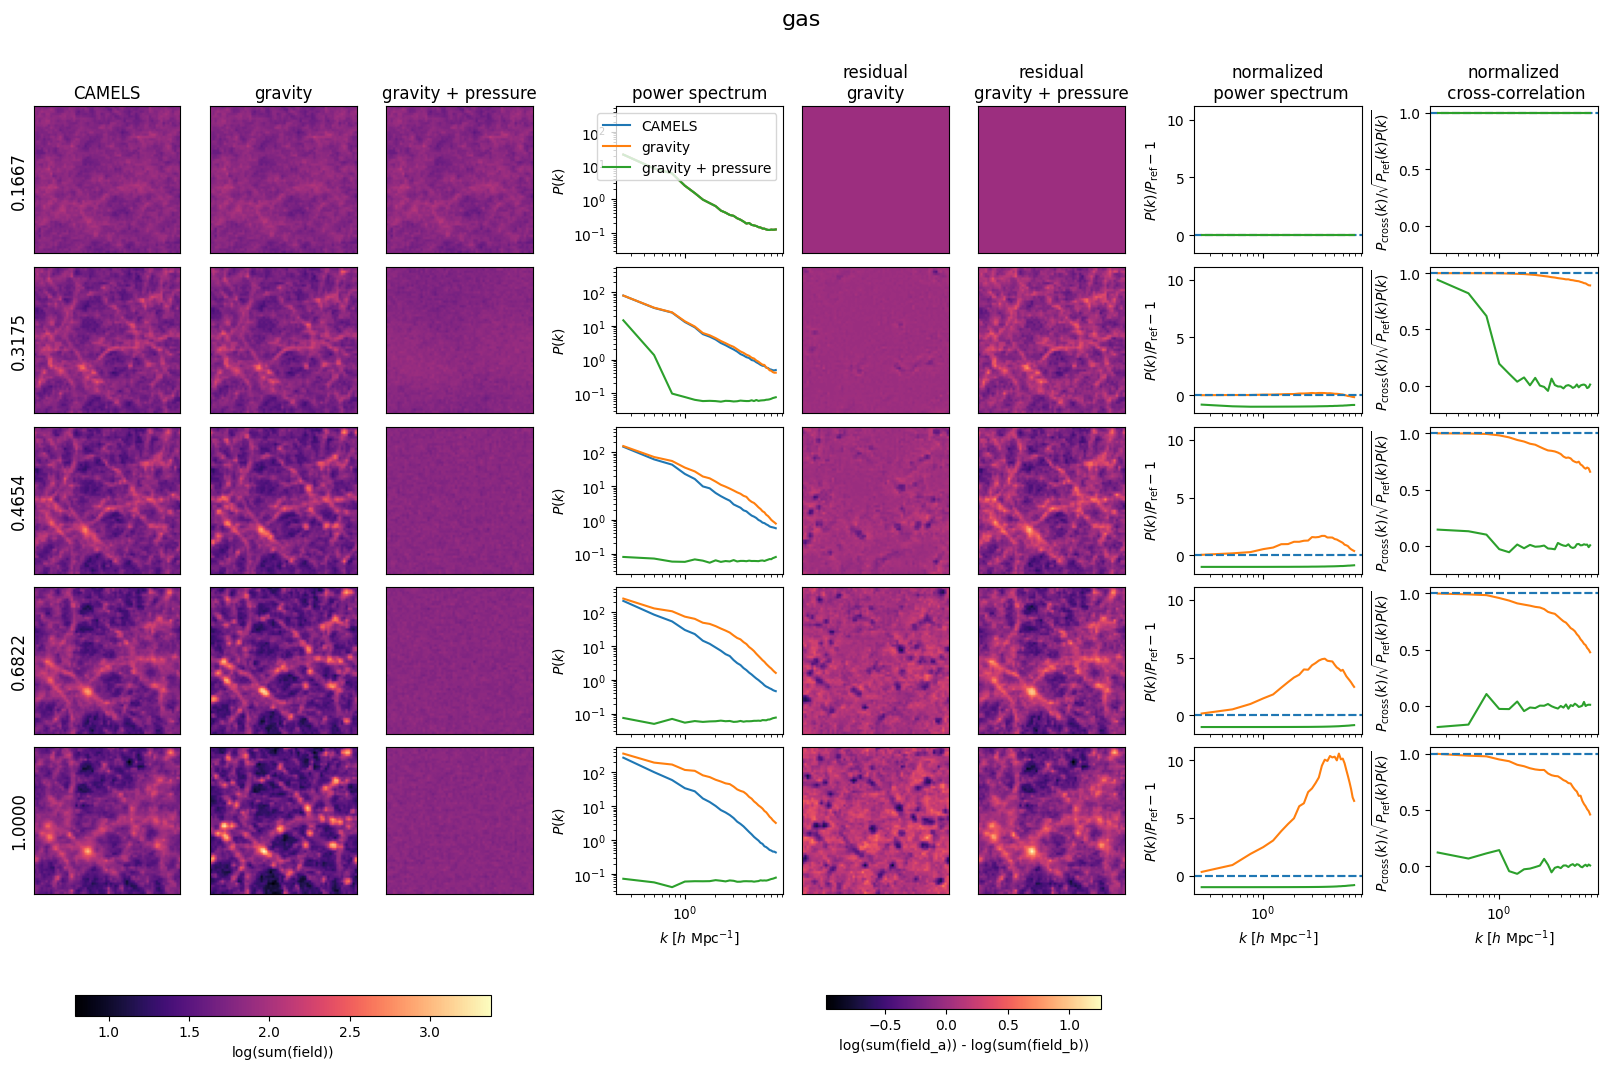

In [59]:
diagnostics.run_simulations(
    # train_dict, 
    out_dict,
    mesh_per_dim, 
    pressure_model=model, 
    gas_architecture=architecture, 
    dt0=dt0, 
    # i_snapshots=np.arange(0,4),
    # i_snapshots=np.arange(10,14),
    # i_snapshots=np.arange(-8,0),
    # i_snapshots=np.arange(-4,0),
    i_snapshots=range(1, 33+8, 8),
)

In [56]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=(scales[-1] - scales[0])/(10*len(scales)),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

dark matter and gas
dark matter and gas
dark matter and gas


E0527 14:26:54.962488  964093 pjrt_stream_executor_client.cc:2826] Execution of replica 0 failed: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/runpy.py", line 198, in _run_module_as_main
  File "/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/runpy.py", line 88, in _run_code
  File "/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/cluster/software/stacks/2

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/cluster/home/athomsen/flatiron/lib/python3.11/site-packages/diffrax/_integrate.py", line 1423, in diffeqsolve
    sol = result.error_if(sol, jnp.invert(is_okay(result)))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
equinox.EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the Python debugger: `u` and `d` to move up and down frames, the name of a variable
to print its value, etc.

2) You may also like to try setting `JAX_DISABLE_JIT=1`. This will mean that you can
(mostly) inspect the state of your program as if it was normal Python.

3) See `https://docs.kidger.site/equin

In [ ]:
nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, pressure_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=(scales[-1] - scales[0])/(10*len(scales)),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

In [ ]:
with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
        title="gas",
        col_titles=["CAMELS", "gravity", "gravity + pressure"],
        include_pk=True,
        include_reference=True,
    )

### latent

In [ ]:
from jax import default_device

In [ ]:
nn_gas_latents.shape

In [ ]:
plt.plot(jnp.sum(nn_gas_latents, axis=(1,2)))

In [ ]:
n_latent = nn_gas_latents.shape[-1]
# n_latent = 3

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, nn_gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N[...,jnp.newaxis] != 0, nn_gas_latents/nn_gas_N[...,jnp.newaxis], nn_gas_latents)
# nn_gas_latents_norm = nn_gas_latents

poss = []
# poss.extend([nn_dm_poss, nn_gas_poss])
poss.extend([nn_gas_poss for _ in range(n_latent)])
poss = jnp.stack(poss, axis=0)

weights = []
# weights.extend([jnp.ones_like(nn_dm_poss[:,:,0]), jnp.ones_like(nn_gas_poss[:,:,0])])
weights.extend([nn_gas_latents_norm[:,:,i] for i in range(n_latent)])
weights = jnp.stack(weights, axis=0)

col_titles = []
# col_titles.extend(["dm", "gas"])
col_titles.extend([f"latent {i}" for i in range(n_latent)])

with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        poss, 
        title="HPM",
        weights=weights,
        col_titles=col_titles,
        shared_colorbar=True,
        log=False,
        arcsinh=True,
    )

In [ ]:
# for i in range(len(scales)):
#     fig, ax = plt.subplots()

#     # ax.hist(nn_gas_latents[i,:])
#     ax.hist(np.arcsinh(nn_gas_latents[i,:]))

# validation

In [ ]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=vali_dict["scales"][0],
        t1=vali_dict["scales"][-1],
        dt0=0.01,
        y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=vali_dict["scales"][0],
        t1=vali_dict["scales"][-1],
        dt0=0.01,
        # y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0]),
        y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([vali_dict["gas_poss"], og_gas_poss, nn_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)

In [ ]:
n_latent = nn_gas_latents.shape[-1]
# n_latent = 3

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N[...,jnp.newaxis] != 0, nn_gas_latents/nn_gas_N[...,jnp.newaxis], nn_gas_latents)

poss = []
# poss.extend([nn_dm_poss, nn_gas_poss])
poss.extend([nn_gas_poss for _ in range(n_latent)])
poss = jnp.stack(poss, axis=0)

weights = []
# weights.extend([jnp.ones_like(nn_dm_poss[:,:,0]), jnp.ones_like(nn_gas_poss[:,:,0])])
weights.extend([nn_gas_latents_norm[:,:,i] for i in range(n_latent)])
weights = jnp.stack(weights, axis=0)

col_titles = []
# col_titles.extend(["dm", "gas"])
col_titles.extend([f"latent {i}" for i in range(n_latent)])

with default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        poss, 
        title="HPM",
        weights=weights,
        col_titles=col_titles,
        shared_colorbar=True,
        log=False,
        arcsinh=True,
    )

# OLD

In [ ]:
stop

In [ ]:
n_latent = nn_gas_latent.shape[-1]

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N[...,jnp.newaxis] != 0, nn_gas_latents/nn_gas_N[...,jnp.newaxis], nn_gas_latents)

poss = [nn_dm_poss, nn_gas_poss]
poss.extend([nn_gas_poss for _ in range(n_latent)])
poss = jnp.stack(poss, axis=0)

weights = [jnp.ones_like(nn_dm_poss[:,:,0]), jnp.ones_like(nn_gas_poss[:,:,0])]
weights.extend([nn_gas_latents_norm[:,:,i] for i in range(n_latent)])
weights = jnp.stack(weights, axis=0)

col_titles = ["dm", "gas"]
col_titles.extend([f"latent {i}" for i in range(n_latent)])

plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    poss, 
    title="HPM",
    weights=weights,
    col_titles=col_titles,
    shared_colorbar=False,
    individual_colorbars=False,
    log=False,
    arcsinh=True,
)

In [ ]:
for weight in weights:
    print(weight.shape)

In [ ]:
nn_gas_latents_norm.shape

In [ ]:
# len(weights)

In [ ]:
weights[0].shape

In [ ]:
weights[1].shape

In [ ]:
weights[2]

In [ ]:
nn_gas_latents = nn_gas_latent[:,:,0]

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N != 0, nn_gas_latents/nn_gas_N, nn_gas_latents)

plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([nn_dm_poss, nn_gas_poss, nn_gas_poss], axis=0), 
    title="HPM",
    weights=jnp.stack([jnp.ones_like(nn_gas_latents), jnp.ones_like(nn_gas_latents), nn_gas_latents_norm]),
    col_titles=["dm", "gas", "latent"],
    shared_colorbar=False,
    individual_colorbars=False,
    log=False,
    arcsinh=True,
)

In [ ]:
nn_gas_latent.shape

In [ ]:
jnp.transpose(nn_gas_latent, (2,0,1)).shape

In [ ]:
nn_gas_latent.shape

In [ ]:
mesh_shape

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.transpose(nn_gas_latent, (2,0,1)),
    title="HPM",
    col_titles=[f"latent {i}" for i in range(nn_gas_latent.shape[-1])],
    shared_colorbar=False,
    individual_colorbars=False,
    log=False,
    arcsinh=True,
)

In [ ]:
plotting.compare_particle_evolution(
    scales,
    jnp.transpose(nn_gas_latent, (2,0,1)),
    include_pk=False,
    include_reference=False,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=[f"latent {i}" for i in range(nn_gas_latent.shape[-1])],
)

# OLD

In [ ]:
# # hpm_gas_latents = jnp.squeeze(hpm_gas_latents)
# hpm_gas_latents = hpm_gas_latents[:,:,0]

# hpm_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), hpm_gas_poss)
# hpm_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(hpm_N_gas, gas_poss)
# hpm_gas_latents_norm = jnp.where(hpm_gas_N != 0, hpm_gas_latents/hpm_gas_N, hpm_gas_latents)

# plotting.compare_particle_evolution(
#     mesh_shape, 
#     scales, 
#     jnp.stack([hpm_dm_poss, hpm_gas_poss, hpm_gas_poss], axis=0), 
#     title="HPM",
#     weights=jnp.stack([jnp.ones_like(hpm_gas_latents), jnp.ones_like(hpm_gas_latents), hpm_gas_latents_norm]),
#     col_titles=["dm", "gas", "latent"],
#     shared_colorbar=False,
#     individual_colorbars=False,
#     log=False,
#     arcsinh=True,
# )

In [ ]:
stop

In [ ]:
pm_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim, cosmo, gravity_model=None, pressure_model=None, integrator_type="diffrax"
)

pm_res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res.ys

In [ ]:
if with_latent:
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init)
else:
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])

hpm_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim, cosmo, gravity_model=None, pressure_model=model, gas_architecture=architecture, integrator_type="diffrax"
)


hpm_res = diffeqsolve(
        terms=ODETerm(hpm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=y0,
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

if with_latent:
    hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels, hpm_gas_latents = hpm_res.ys
else:
    hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res.ys

### comparison with CAMELS

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([gas_poss, pm_gas_poss, hpm_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
    arcsinh=False
)